In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os
import time

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')  # Update this line
sns.set_palette('viridis')

In [2]:
def load_transformed_dataset():
    """
    Load the transformed dataset from the previous notebook.
    """
    # Path to the transformed dataset
    transformed_path = '../../data/processed/transformed_dataset.csv'
    
    if os.path.exists(transformed_path):
        print(f"Loading transformed dataset from: {transformed_path}")
        try:
            df = pd.read_csv(transformed_path)
            print(f"Loaded transformed dataset: {df.shape[0]} rows, {df.shape[1]} columns")
            return df
        except Exception as e:
            print(f"Error loading transformed file {transformed_path}: {e}")
            return None
    else:
        print(f"Transformed dataset not found at {transformed_path}. Please run feature_transformations.ipynb first.")
        return None

# Load the transformed dataset
df_transformed = load_transformed_dataset()

# Display basic info if loaded successfully
if df_transformed is not None:
    print("\nDataFrame loaded successfully. Basic info:")
    df_transformed.info()
    
    # Display attack type distribution
    if 'attack_type' in df_transformed.columns:
        print("\nAttack type distribution:")
        print(df_transformed['attack_type'].value_counts())
else:
    print("\nDataFrame could not be loaded. Cannot proceed.")
    # You might want to raise an exception here to stop execution

Loading transformed dataset from: ../../data/processed/transformed_dataset.csv
Loaded transformed dataset: 2000 rows, 83 columns

DataFrame loaded successfully. Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 83 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dst Port           2000 non-null   int64  
 1   Protocol           2000 non-null   int64  
 2   Timestamp          2000 non-null   object 
 3   Flow Duration      2000 non-null   float64
 4   Tot Fwd Pkts       2000 non-null   float64
 5   Tot Bwd Pkts       2000 non-null   float64
 6   TotLen Fwd Pkts    2000 non-null   float64
 7   TotLen Bwd Pkts    2000 non-null   float64
 8   Fwd Pkt Len Max    2000 non-null   float64
 9   Fwd Pkt Len Min    2000 non-null   float64
 10  Fwd Pkt Len Mean   2000 non-null   float64
 11  Fwd Pkt Len Std    2000 non-null   float64
 12  Bwd Pkt Len Max    2000 non-null   float64



Selected 77 numerical features for analysis.


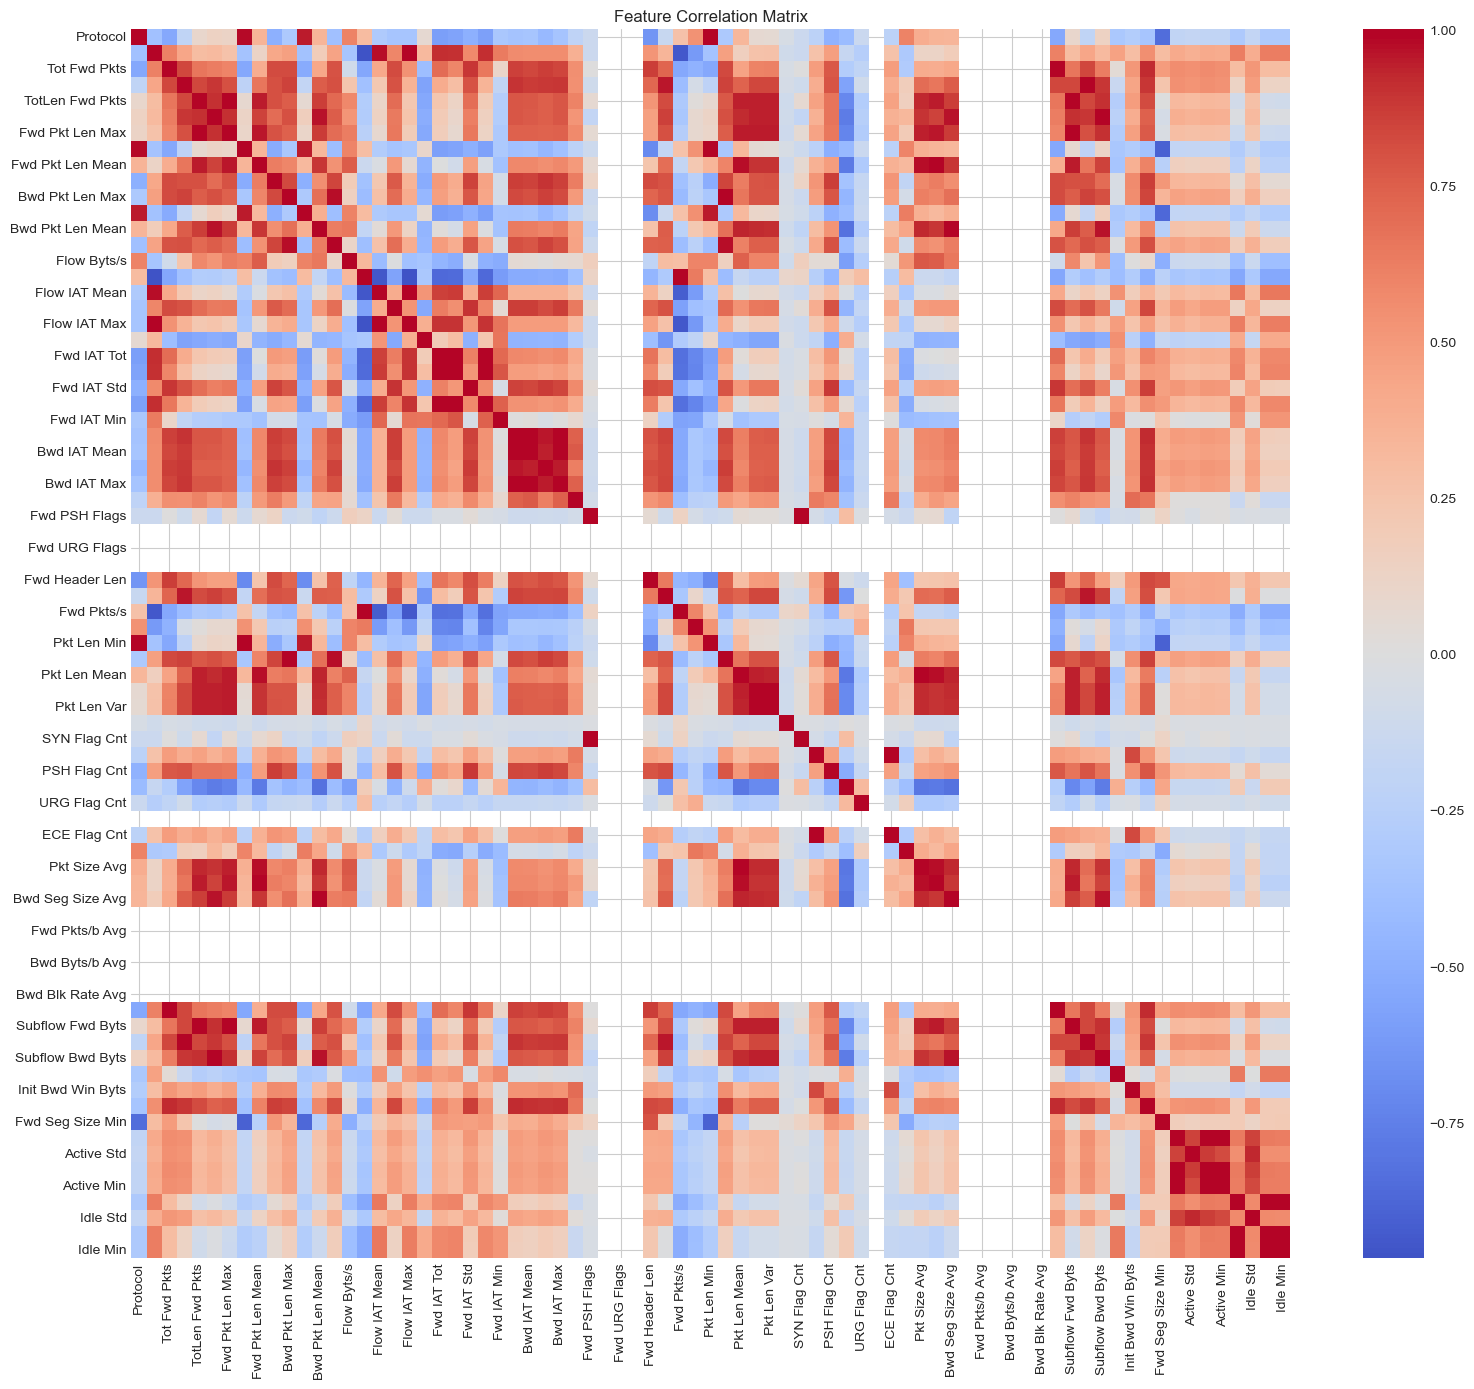


Top correlated feature pairs:
Tot Fwd Pkts <-> Subflow Fwd Pkts: 1.0000
Tot Bwd Pkts <-> Subflow Bwd Pkts: 1.0000
TotLen Fwd Pkts <-> Subflow Fwd Byts: 1.0000
TotLen Bwd Pkts <-> Subflow Bwd Byts: 1.0000
Fwd Pkt Len Mean <-> Fwd Seg Size Avg: 1.0000
Bwd Pkt Len Mean <-> Bwd Seg Size Avg: 1.0000
Fwd PSH Flags <-> SYN Flag Cnt: 1.0000
RST Flag Cnt <-> ECE Flag Cnt: 1.0000
Idle Mean <-> Idle Max: 1.0000
Idle Mean <-> Idle Min: 0.9999


In [3]:
# First we need to define feature_cols
if df_transformed is not None:
    # Select numerical features, excluding identifiers and labels
    numerical_features = df_transformed.select_dtypes(include=np.number).columns.tolist()
    
    # Define columns to exclude
    exclude_cols = ['is_attack', 'Timestamp', 'Src Port', 'Dst Port']
    
    # Filter out labels and identifiers
    feature_cols = [
        col for col in numerical_features
        if col not in exclude_cols and '_Id' not in col
    ]
    
    print(f"\nSelected {len(feature_cols)} numerical features for analysis.")

    def analyze_feature_correlations(df, feature_cols):
        """Analyze correlations between features"""
        # Calculate correlation matrix
        corr_matrix = df[feature_cols].corr()
        
        # Plot correlation heatmap
        plt.figure(figsize=(16, 14))
        sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Matrix')
        plt.tight_layout()
        plt.show()
        
        # Find correlated feature pairs
        correlated_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.5:  # Moderately correlated
                    correlated_pairs.append({
                        'feature1': corr_matrix.columns[i],
                        'feature2': corr_matrix.columns[j],
                        'correlation': corr_matrix.iloc[i, j]
                    })
                    
        # Sort by absolute correlation value
        correlated_pairs = sorted(correlated_pairs, key=lambda x: abs(x['correlation']), reverse=True)
        return correlated_pairs
    
    # Analyze correlations
    correlated_pairs = analyze_feature_correlations(df_transformed, feature_cols)
    
    # Display top correlated pairs
    if correlated_pairs:
        print("\nTop correlated feature pairs:")
        for pair in correlated_pairs[:10]:
            print(f"{pair['feature1']} <-> {pair['feature2']}: {pair['correlation']:.4f}")
    else:
        print("\nNo significantly correlated feature pairs found.")

In [4]:
def create_ratio_features(df):
    """Create ratio-based features"""
    print("\nCreating ratio-based features...")
    df_with_ratios = df.copy()
    
    # Track created features
    created_features = []
    
    # Packet size ratios
    if all(col in df.columns for col in ['Fwd Pkt Len Max', 'Bwd Pkt Len Max']):
        df_with_ratios['Pkt_Size_Ratio'] = df['Fwd Pkt Len Max'] / (df['Bwd Pkt Len Max'] + 1)
        created_features.append('Pkt_Size_Ratio')
        print(" - Created 'Pkt_Size_Ratio'")
    
    # Timing ratios
    if all(col in df.columns for col in ['Flow IAT Max', 'Flow IAT Min']):
        df_with_ratios['IAT_Ratio'] = df['Flow IAT Max'] / (df['Flow IAT Min'] + 1)
        created_features.append('IAT_Ratio')
        print(" - Created 'IAT_Ratio'")
    
    # Packet count normalized by duration
    if all(col in df.columns for col in ['Tot Fwd Pkts', 'Flow Duration']):
        df_with_ratios['Pkts_Per_Second'] = df['Tot Fwd Pkts'] / ((df['Flow Duration'] / 1000000) + 0.001)
        created_features.append('Pkts_Per_Second')
        print(" - Created 'Pkts_Per_Second'")
    
    # Flag combinations
    flag_columns = [col for col in df.columns if 'Flag Cnt' in col]
    if len(flag_columns) >= 3:
        df_with_ratios['Flag_Combination'] = 0
        if 'ACK Flag Cnt' in df.columns:
            df_with_ratios['Flag_Combination'] += df['ACK Flag Cnt']
        if 'PSH Flag Cnt' in df.columns:
            df_with_ratios['Flag_Combination'] += 2 * df['PSH Flag Cnt']
        if 'RST Flag Cnt' in df.columns:
            df_with_ratios['Flag_Combination'] += 4 * df['RST Flag Cnt']
        created_features.append('Flag_Combination')
        print(" - Created 'Flag_Combination'")
    
    # Handle potential NaN/Inf values in new features
    for feature in created_features:
        df_with_ratios[feature].replace([np.inf, -np.inf], np.nan, inplace=True)
        nan_count = df_with_ratios[feature].isna().sum()
        if nan_count > 0:
            print(f" - Warning: {nan_count} NaN values in '{feature}' after creation")
            # Fill with median or 0
            if df_with_ratios[feature].notna().any():
                median_val = df_with_ratios[feature].median()
                df_with_ratios[feature].fillna(median_val, inplace=True)
                print(f"   - Filled with median: {median_val:.4f}")
            else:
                df_with_ratios[feature].fillna(0, inplace=True)
                print(f"   - Filled with 0 (all values were NaN)")
    
    print(f"Created {len(created_features)} ratio-based features")
    return df_with_ratios

if df_transformed is not None:
    # Create ratio features
    df_with_ratios = create_ratio_features(df_transformed)
    
    # Show new columns
    new_columns = [col for col in df_with_ratios.columns if col not in df_transformed.columns]
    if new_columns:
        print(f"\nNew ratio features created: {new_columns}")
        print("\nSample values:")
        print(df_with_ratios[new_columns].head())
    else:
        print("\nNo new ratio features were created.")


Creating ratio-based features...
 - Created 'Pkt_Size_Ratio'
 - Created 'IAT_Ratio'
 - Created 'Pkts_Per_Second'
 - Created 'Flag_Combination'
Created 4 ratio-based features

New ratio features created: ['Pkt_Size_Ratio', 'IAT_Ratio', 'Pkts_Per_Second', 'Flag_Combination']

Sample values:
   Pkt_Size_Ratio  IAT_Ratio  Pkts_Per_Second  Flag_Combination
0        3.361999   3.046723      2793.154351          2.000000
1        5.180716   4.021599      1764.538656          4.772589
2        5.105594   2.759123      1921.602612          1.000000
3        0.000000   0.836865      1093.005282          1.000000
4        0.000000   0.946819      1079.395162          1.000000


In [5]:
def create_attack_specific_features(df):
    """Create features specifically designed to detect certain attack types"""
    print("\nCreating attack-specific features...")
    df_with_attack_features = df.copy()
    
    # Track created features
    created_features = []
    
    # SQL Injection features based on Phase 1 findings
    if all(col in df.columns for col in ['RST Flag Cnt', 'Bwd Pkt Len Max']):
        try:
            df_with_attack_features['SQL_Injection_Score'] = df['RST Flag Cnt'] * df['Bwd Pkt Len Max'] / 100
            created_features.append('SQL_Injection_Score')
            print(" - Created 'SQL_Injection_Score'")
        except Exception as e:
            print(f" - Error creating 'SQL_Injection_Score': {e}")
    
    # Brute Force features
    if all(col in df.columns for col in ['TotLen Fwd Pkts', 'Tot Fwd Pkts']):
        try:
            df_with_attack_features['Brute_Force_Score'] = df['TotLen Fwd Pkts'] * df['Tot Fwd Pkts'] / 1000
            created_features.append('Brute_Force_Score')
            print(" - Created 'Brute_Force_Score'")
        except Exception as e:
            print(f" - Error creating 'Brute_Force_Score': {e}")
    
    # XSS features
    if all(col in df.columns for col in ['TotLen Fwd Pkts', 'Tot Fwd Pkts', 'Pkt Len Var']):
        try:
            df_with_attack_features['XSS_Score'] = df['TotLen Fwd Pkts'] * df['Tot Fwd Pkts'] * df['Pkt Len Var'] / 1000000
            created_features.append('XSS_Score')
            print(" - Created 'XSS_Score'")
        except Exception as e:
            print(f" - Error creating 'XSS_Score': {e}")
    
    # Handle potential NaN/Inf values in new features
    for feature in created_features:
        df_with_attack_features[feature].replace([np.inf, -np.inf], np.nan, inplace=True)
        nan_count = df_with_attack_features[feature].isna().sum()
        if nan_count > 0:
            print(f" - Warning: {nan_count} NaN values in '{feature}' after creation")
            # Fill with median or 0
            if df_with_attack_features[feature].notna().any():
                median_val = df_with_attack_features[feature].median()
                df_with_attack_features[feature].fillna(median_val, inplace=True)
                print(f"   - Filled with median: {median_val:.4f}")
            else:
                df_with_attack_features[feature].fillna(0, inplace=True)
                print(f"   - Filled with 0 (all values were NaN)")
    
    print(f"Created {len(created_features)} attack-specific features")
    return df_with_attack_features

if 'df_with_ratios' in locals() and df_with_ratios is not None:
    # Create attack-specific features
    df_with_attack_features = create_attack_specific_features(df_with_ratios)
    
    # Show new columns
    new_columns = [col for col in df_with_attack_features.columns if col not in df_with_ratios.columns]
    if new_columns:
        print(f"\nNew attack-specific features created: {new_columns}")
        print("\nSample values:")
        print(df_with_attack_features[new_columns].head())
    else:
        print("\nNo new attack-specific features were created.")


Creating attack-specific features...
 - Created 'SQL_Injection_Score'
 - Created 'Brute_Force_Score'
 - Created 'XSS_Score'
Created 3 attack-specific features

New attack-specific features created: ['SQL_Injection_Score', 'Brute_Force_Score', 'XSS_Score']

Sample values:
   SQL_Injection_Score  Brute_Force_Score  XSS_Score
0             0.000000           0.019833   0.000214
1             0.001728           0.011597   0.000126
2             0.000000           0.015874   0.000193
3             0.000000           0.000000   0.000000
4             0.000000           0.000000   0.000000



Analyzing new features by attack type (2 types)...
Analyzing 9 new features: ['Dst Port', 'Timestamp', 'Pkt_Size_Ratio', 'IAT_Ratio', 'Pkts_Per_Second', 'Flag_Combination', 'SQL_Injection_Score', 'Brute_Force_Score', 'XSS_Score']

Analyzing feature: Dst Port
 - Limited 20 extreme values for plotting
 - Using 201 samples for plotting


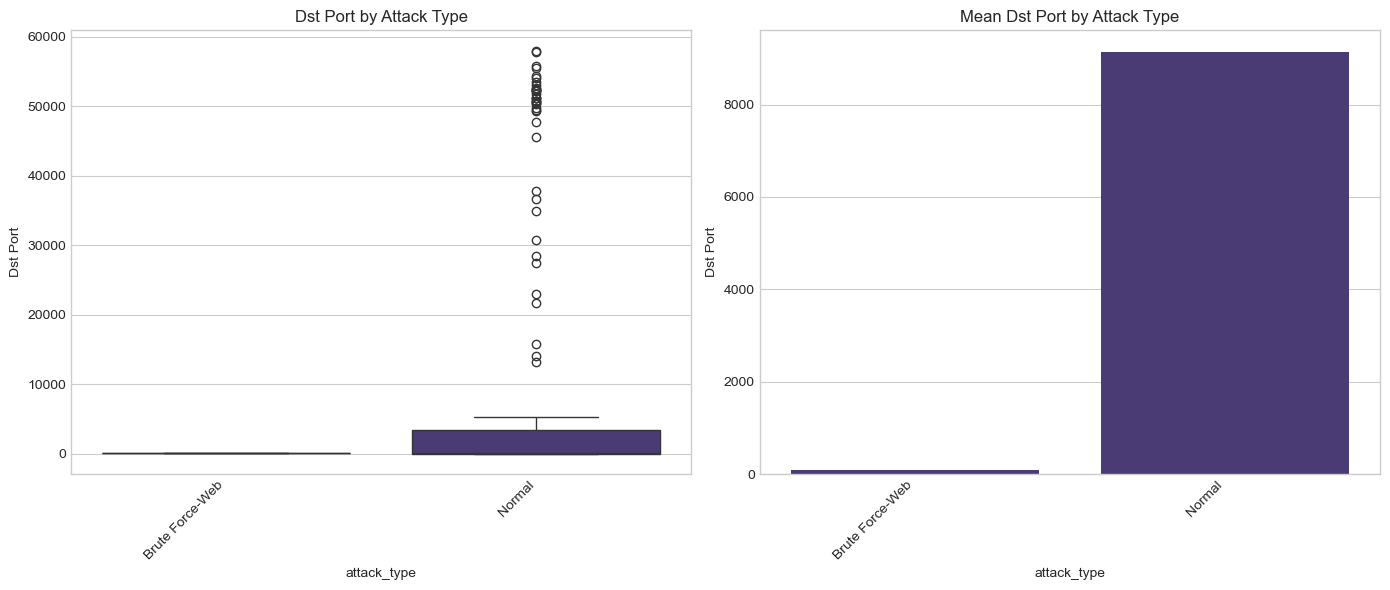


Feature: Dst Port - Statistics by Attack Type
Normal: 9148.4787
Brute Force-Web: 80.0000 (-99.1% compared to Normal)

Analyzing feature: Timestamp
 - Error analyzing Timestamp: unsupported operand type(s) for -: 'str' and 'str'

Analyzing feature: Pkt_Size_Ratio
 - Limited 20 extreme values for plotting
 - Using 201 samples for plotting


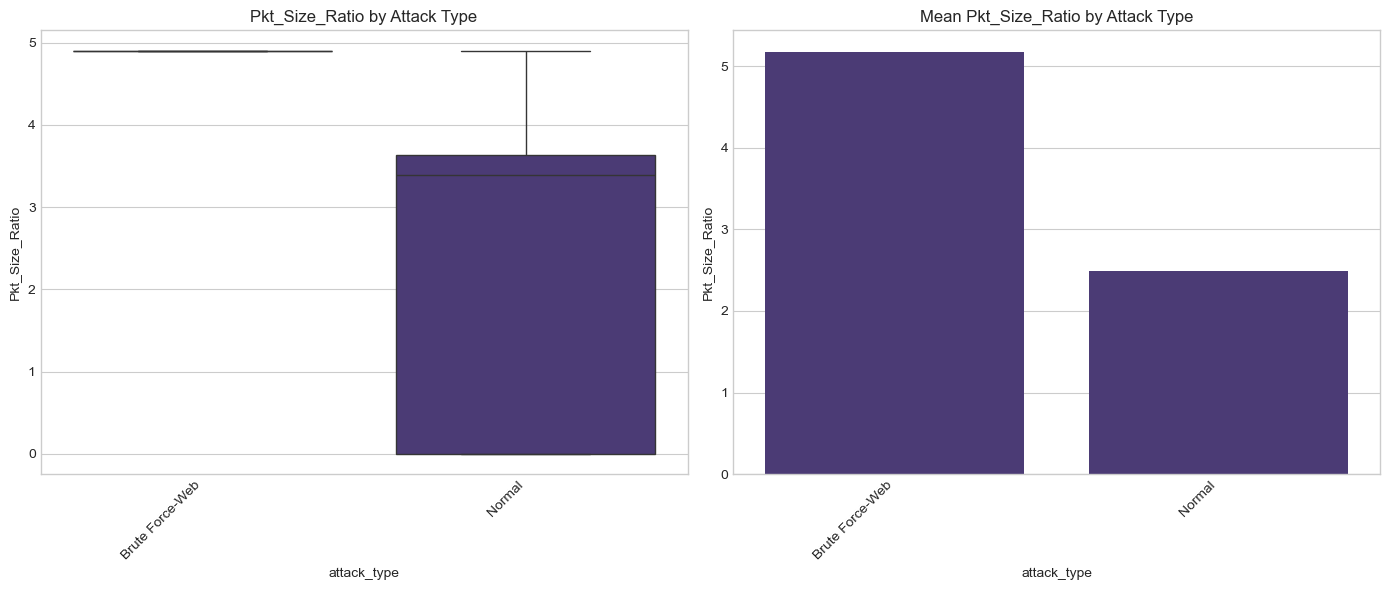


Feature: Pkt_Size_Ratio - Statistics by Attack Type
Normal: 2.4946
Brute Force-Web: 5.1807 (107.7% compared to Normal)

Analyzing feature: IAT_Ratio
 - Limited 33 extreme values for plotting
 - Using 201 samples for plotting


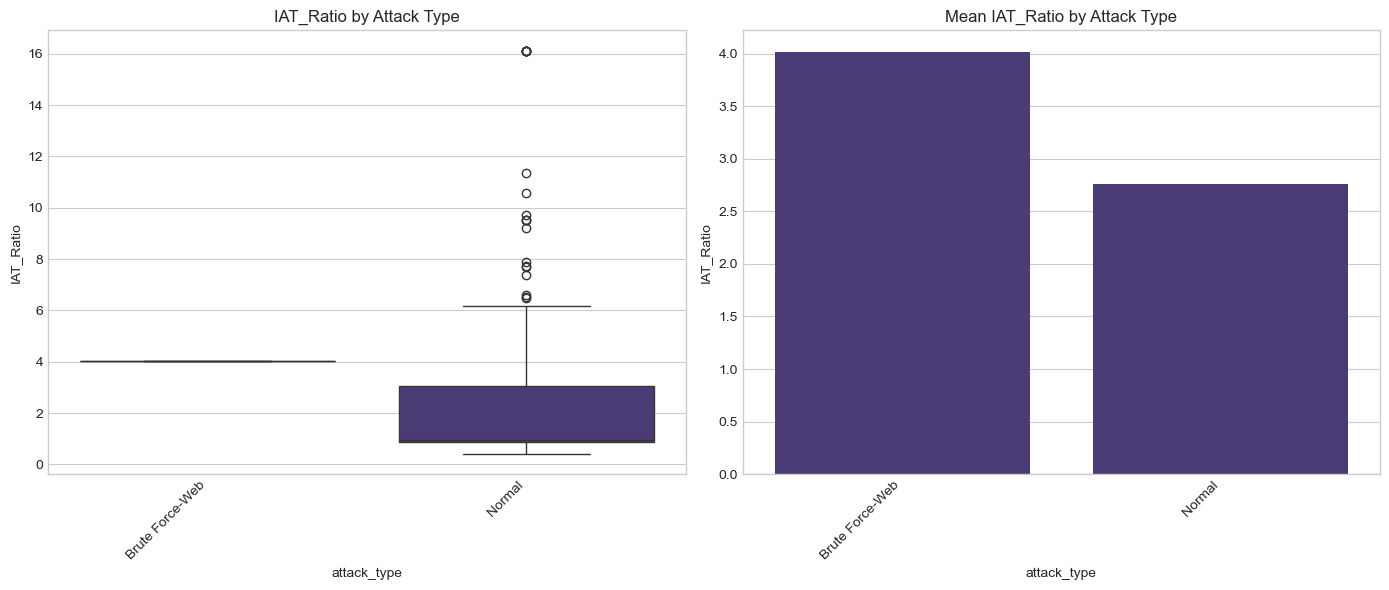


Feature: IAT_Ratio - Statistics by Attack Type
Normal: 2.7608
Brute Force-Web: 4.0216 (45.7% compared to Normal)

Analyzing feature: Pkts_Per_Second
 - Limited 40 extreme values for plotting
 - Using 201 samples for plotting


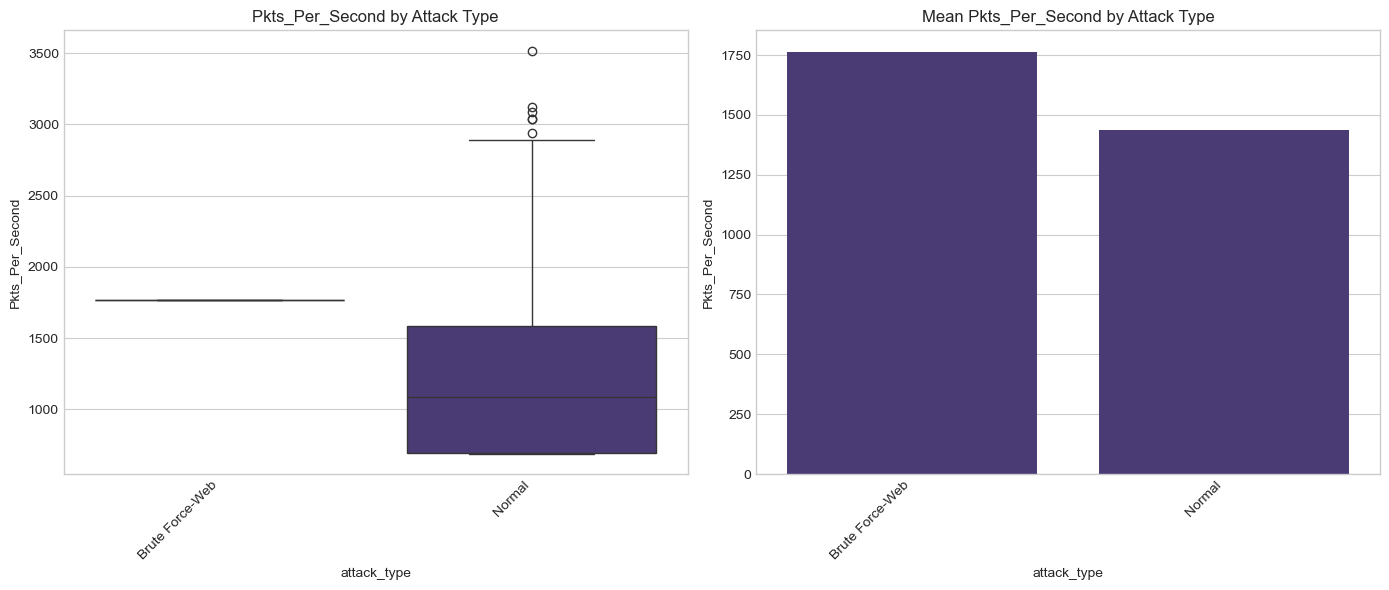


Feature: Pkts_Per_Second - Statistics by Attack Type
Normal: 1438.6782
Brute Force-Web: 1764.5387 (22.6% compared to Normal)

Analyzing feature: Flag_Combination
 - Using 201 samples for plotting


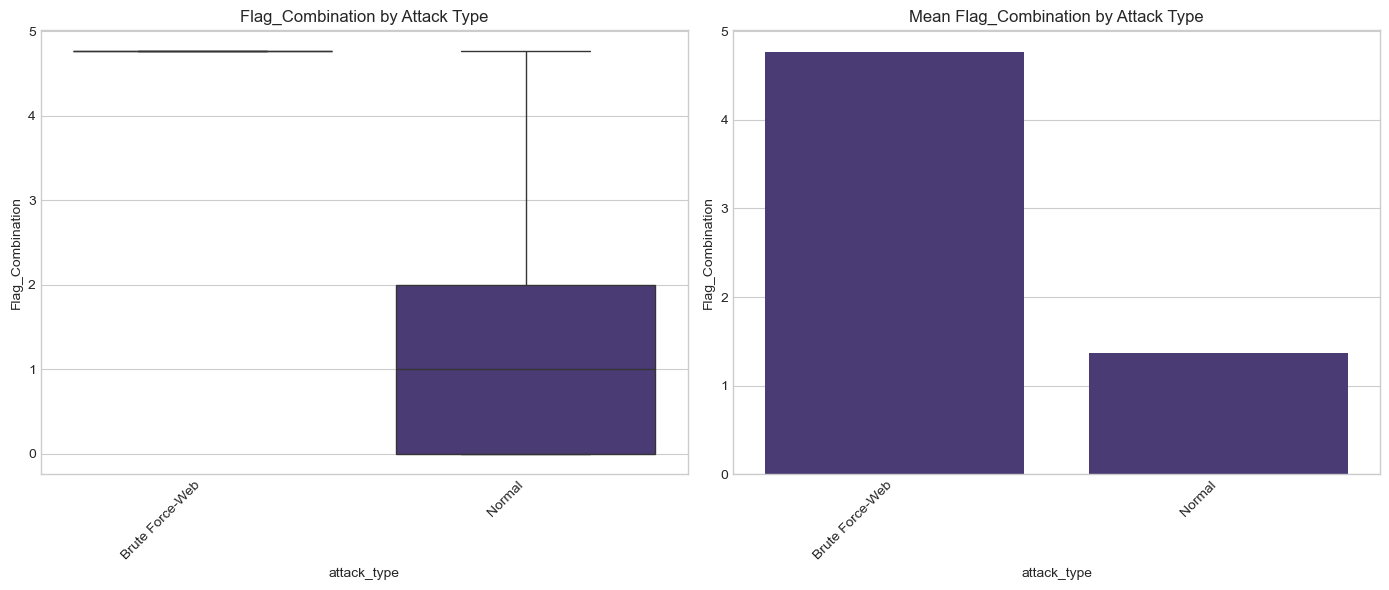


Feature: Flag_Combination - Statistics by Attack Type
Normal: 1.3679
Brute Force-Web: 4.7726 (248.9% compared to Normal)

Analyzing feature: SQL_Injection_Score
 - Using 201 samples for plotting


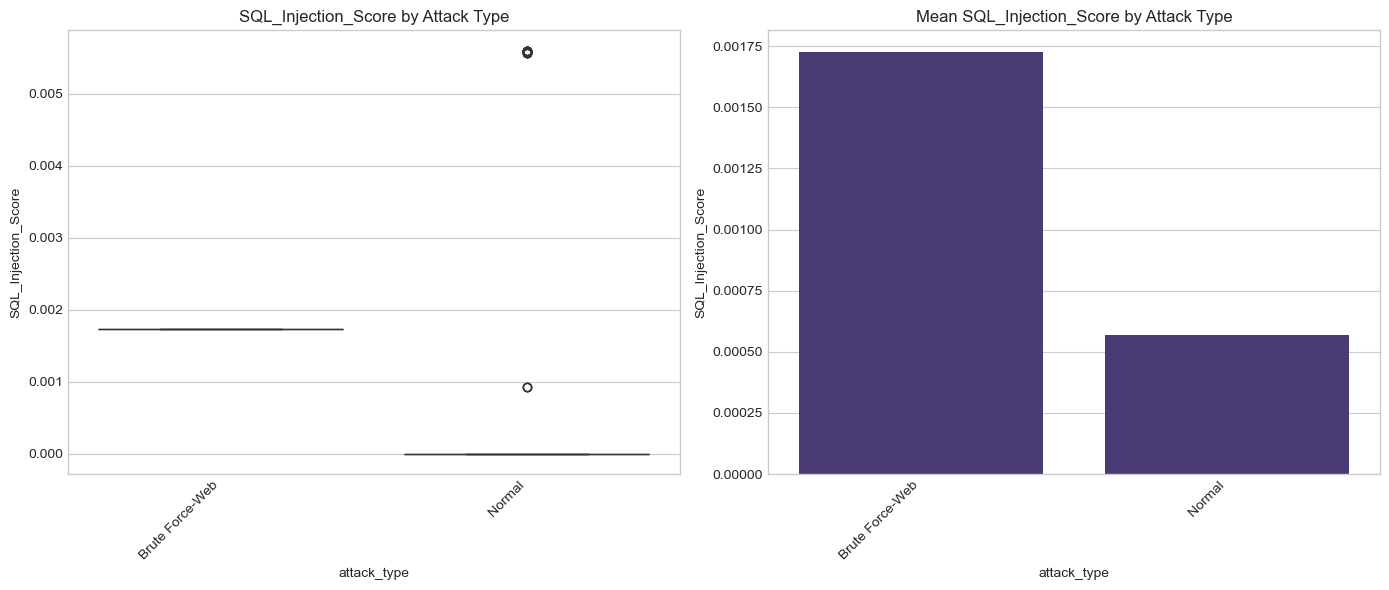


Feature: SQL_Injection_Score - Statistics by Attack Type
Normal: 0.0006
Brute Force-Web: 0.0017 (203.4% compared to Normal)

Analyzing feature: Brute_Force_Score
 - Limited 20 extreme values for plotting
 - Using 201 samples for plotting


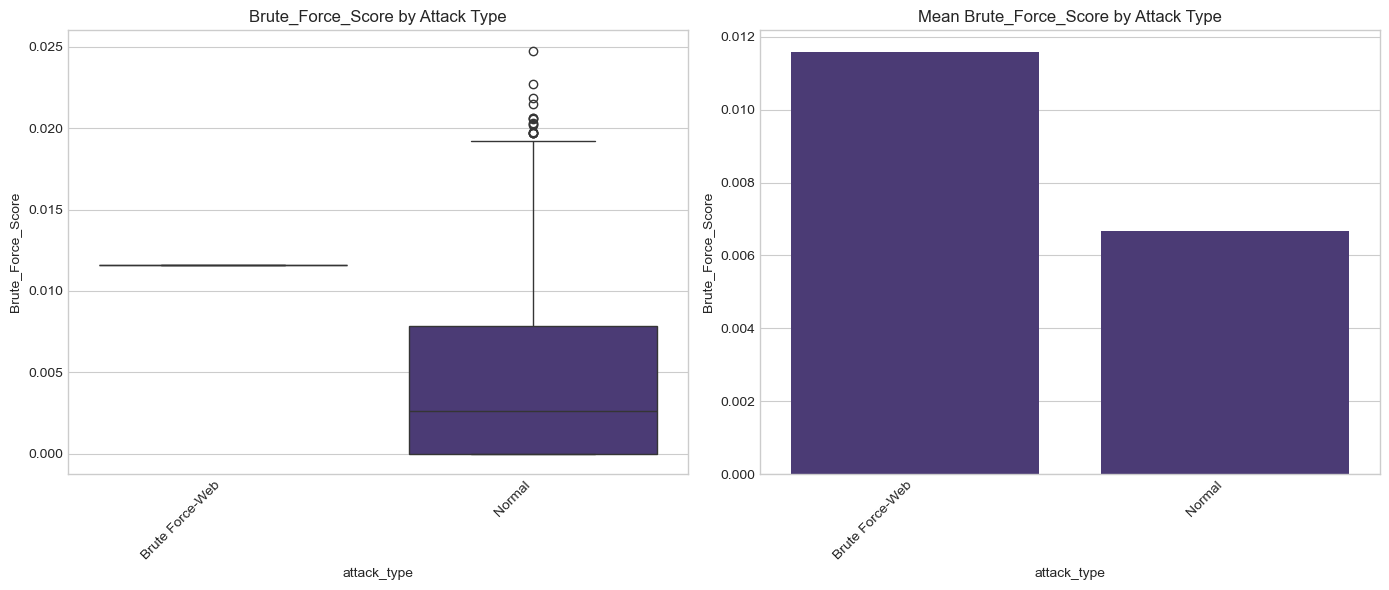


Feature: Brute_Force_Score - Statistics by Attack Type
Normal: 0.0067
Brute Force-Web: 0.0116 (73.6% compared to Normal)

Analyzing feature: XSS_Score
 - Limited 20 extreme values for plotting
 - Using 201 samples for plotting


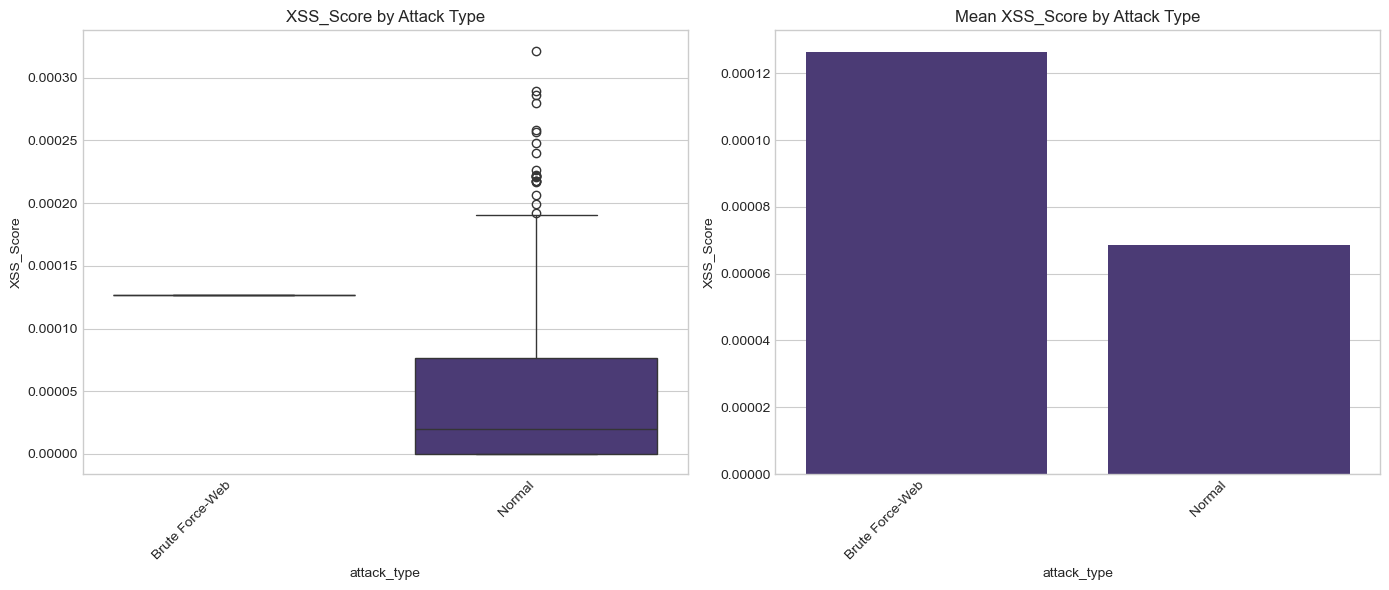


Feature: XSS_Score - Statistics by Attack Type
Normal: 0.0001
Brute Force-Web: 0.0001 (84.6% compared to Normal)

Feature analysis complete

Enhanced features dataset saved to ../../data/processed/enhanced_features_dataset.csv
Feature information saved to ../../src/models/feature_info.json


In [6]:
def analyze_new_features_by_attack_type(df, feature_cols):
    """Analyze how new features vary by attack type"""
    if 'attack_type' not in df.columns:
        print("Error: 'attack_type' column not found in DataFrame. Cannot analyze by attack type.")
        return
    
    attack_types = df['attack_type'].unique()
    print(f"\nAnalyzing new features by attack type ({len(attack_types)} types)...")
    
    # Get only new features (not in original feature set)
    new_features = [col for col in df.columns 
                   if col not in feature_cols 
                   and col not in ['is_attack', 'attack_type', 'Label', 'source']]
    
    if not new_features:
        print("No new features to analyze.")
        return
    
    print(f"Analyzing {len(new_features)} new features: {new_features}")
    
    for feature in new_features:
        print(f"\nAnalyzing feature: {feature}")
        try:
            # Check for extreme values that might cause plotting issues
            percentiles = df[feature].quantile([0.01, 0.99]).values
            lower_bound, upper_bound = percentiles[0], percentiles[1]
            
            # Create a copy of the data for plotting, limiting extreme outliers
            plot_df = df.copy()
            extremely_low = plot_df[feature] < lower_bound
            extremely_high = plot_df[feature] > upper_bound
            extreme_count = extremely_low.sum() + extremely_high.sum()
            
            if extreme_count > 0:
                print(f" - Limited {extreme_count} extreme values for plotting")
                # Replace extreme values for plotting purposes only
                plot_df.loc[extremely_low, feature] = lower_bound
                plot_df.loc[extremely_high, feature] = upper_bound
            
            # Subset data to keep plots manageable
            if len(plot_df) > 1000:
                plot_sample = plot_df.groupby('attack_type', group_keys=False).apply(
                    lambda x: x.sample(min(200, len(x)), random_state=42)
                )
                print(f" - Using {len(plot_sample)} samples for plotting")
            else:
                plot_sample = plot_df
            
            plt.figure(figsize=(14, 6))
            
            # Boxplot by attack type
            plt.subplot(1, 2, 1)
            sns.boxplot(x='attack_type', y=feature, data=plot_sample)
            plt.xticks(rotation=45, ha='right')
            plt.title(f'{feature} by Attack Type')
            
            # Calculate and show means
            means = df.groupby('attack_type')[feature].mean().reset_index()
            
            # Bar plot of means
            plt.subplot(1, 2, 2)
            sns.barplot(x='attack_type', y=feature, data=means)
            plt.xticks(rotation=45, ha='right')
            plt.title(f'Mean {feature} by Attack Type')
            
            plt.tight_layout()
            plt.show()
            
            # Print statistics
            print(f"\nFeature: {feature} - Statistics by Attack Type")
            normal_mean = df[df['attack_type'] == 'Normal'][feature].mean()
            
            for attack_type in attack_types:
                mean_val = df[df['attack_type'] == attack_type][feature].mean()
                if attack_type != 'Normal' and normal_mean != 0:
                    percent_diff = 100 * (mean_val - normal_mean) / abs(normal_mean)
                    print(f"{attack_type}: {mean_val:.4f} ({percent_diff:.1f}% compared to Normal)")
                else:
                    print(f"{attack_type}: {mean_val:.4f}")
                    
        except Exception as e:
            print(f" - Error analyzing {feature}: {e}")
            plt.close()
    
    print("\nFeature analysis complete")

if 'df_with_attack_features' in locals() and df_with_attack_features is not None and 'feature_cols' in locals():
    # Analyze new features
    analyze_new_features_by_attack_type(df_with_attack_features, feature_cols)
    
    # Save the enhanced dataset
    output_path = '../../data/processed/enhanced_features_dataset.csv'
    try:
        # Ensure directory exists
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        
        # Save the dataset
        df_with_attack_features.to_csv(output_path, index=False)
        print(f"\nEnhanced features dataset saved to {output_path}")
        
        # Also save feature information for next notebook
        feature_info = {
            'original_features': feature_cols,
            'ratio_features': [col for col in df_with_ratios.columns 
                              if col not in df_transformed.columns],
            'attack_specific_features': [col for col in df_with_attack_features.columns 
                                        if col not in df_with_ratios.columns]
        }
        
        feature_info_path = '../../src/models/feature_info.json'
        with open(feature_info_path, 'w') as f:
            import json
            json.dump(feature_info, f, indent=4)
        
        print(f"Feature information saved to {feature_info_path}")
        
    except Exception as e:
        print(f"Error saving dataset: {e}")